# SegFormer-B0 Binary Ground / Non-ground Segmentation on RUGD

This notebook follows the same pipeline as the U-Net / SegFormer-B0 binary notebook:
processed RUGD masks `0–23/255` → binary remap `0=non-ground, 1=ground, 255=ignore` → SegFormer-B0 training → validation → test evaluation → qualitative analysis.

Model:
- `segmentation_models_pytorch.Segformer`
- encoder: `mit_b0`
- output classes: `2`


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
from pathlib import Path
import zipfile

processed_zip_path = Path("/content/drive/MyDrive/IRP/01_data/processed/RUGD_processed.zip")
extract_dir = Path("/content")

with zipfile.ZipFile(processed_zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

print("Unzipped processed dataset.")


Unzipped processed dataset.


In [ ]:
from pathlib import Path

candidate_paths = [
    Path("/content/RUGD_processed"),
    Path("/content/content/RUGD_processed"),
]

PROCESSED_ROOT = None

for p in candidate_paths:
    if (p / "images").exists() and (p / "masks").exists():
        PROCESSED_ROOT = p
        break

if PROCESSED_ROOT is None:
    matches = list(Path("/content").rglob("RUGD_processed"))
    print("Found matches:", matches)
    raise RuntimeError("Could not automatically locate RUGD_processed.")

print("PROCESSED_ROOT:", PROCESSED_ROOT)
print("Train images:", len(list((PROCESSED_ROOT / "images" / "train").glob("*.png"))))
print("Train masks:", len(list((PROCESSED_ROOT / "masks" / "train").glob("*.png"))))
print("Val images:", len(list((PROCESSED_ROOT / "images" / "val").glob("*.png"))))
print("Val masks:", len(list((PROCESSED_ROOT / "masks" / "val").glob("*.png"))))


PROCESSED_ROOT: /content/content/RUGD_processed
Train images: 4859
Train masks: 4859
Val images: 1095
Val masks: 1095


In [ ]:
import torch
from torch.utils.data import Dataset
from pathlib import Path
from PIL import Image
import numpy as np

IGNORE_INDEX = 255

# Processed RUGD 24-class train IDs:
# 0=dirt, 1=sand, 2=grass, 3=tree, 4=pole, 5=water,
# 6=sky, 7=vehicle, 8=container/generic-object, 9=asphalt,
# 10=gravel, 11=building, 12=mulch, 13=rock-bed, 14=log,
# 15=bicycle, 16=person, 17=fence, 18=bush, 19=sign,
# 20=rock, 21=bridge, 22=concrete, 23=picnic-table, 255=ignore.

GROUND_IDS = {
    0,   # dirt
    1,   # sand
    2,   # grass
    9,   # asphalt
    10,  # gravel
    12,  # mulch
    13,  # rock-bed
    22,  # concrete
}

NON_GROUND_IDS = {
    3,   # tree
    4,   # pole
    6,   # sky
    7,   # vehicle
    8,   # container/generic-object
    11,  # building
    14,  # log
    15,  # bicycle
    16,  # person
    17,  # fence
    18,  # bush
    19,  # sign
    20,  # rock
    23,  # picnic-table
}

# Ambiguous classes are left as ignore by default:
# 5=water, 21=bridge

BINARY_ID_TO_CLASS = {
    0: "non-ground",
    1: "ground",
}


def remap_24class_to_binary(mask_24: np.ndarray) -> np.ndarray:
    binary_mask = np.full(mask_24.shape, IGNORE_INDEX, dtype=np.uint8)

    for class_id in GROUND_IDS:
        binary_mask[mask_24 == class_id] = 1

    for class_id in NON_GROUND_IDS:
        binary_mask[mask_24 == class_id] = 0

    return binary_mask


class RUGDProcessedBinaryDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = Path(image_dir)
        self.mask_dir = Path(mask_dir)
        self.transform = transform

        self.image_paths = sorted(self.image_dir.glob("*.png"))

        if len(self.image_paths) == 0:
            raise RuntimeError(f"No images found in {self.image_dir}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        mask_path = self.mask_dir / image_path.name

        if not mask_path.exists():
            raise FileNotFoundError(f"Missing mask: {mask_path}")

        image = np.array(Image.open(image_path).convert("RGB"))
        mask_24 = np.array(Image.open(mask_path))
        mask_binary = remap_24class_to_binary(mask_24)

        if self.transform is not None:
            transformed = self.transform(image=image, mask=mask_binary)
            image = transformed["image"]
            mask_binary = transformed["mask"].long()
        else:
            image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
            mask_binary = torch.from_numpy(mask_binary).long()

        return image, mask_binary


In [ ]:
!pip install -q albumentations opencv-python tqdm


In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose([
    A.Resize(512, 512),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.HueSaturationValue(p=0.2),
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
    ),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(512, 512),
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
    ),
    ToTensorV2(),
])


In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 8

train_dataset = RUGDProcessedBinaryDataset(
    image_dir=PROCESSED_ROOT / "images" / "train",
    mask_dir=PROCESSED_ROOT / "masks" / "train",
    transform=train_transform,
)

val_dataset = RUGDProcessedBinaryDataset(
    image_dir=PROCESSED_ROOT / "images" / "val",
    mask_dir=PROCESSED_ROOT / "masks" / "val",
    transform=val_transform,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

print("Train dataset:", len(train_dataset))
print("Val dataset:", len(val_dataset))
print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))


Train dataset: 4859
Val dataset: 1095
Train batches: 608
Val batches: 137


In [ ]:
images, masks = next(iter(train_loader))

print("Images shape:", images.shape)
print("Images dtype:", images.dtype)
print("Masks shape:", masks.shape)
print("Masks dtype:", masks.dtype)
print("Unique mask values:", torch.unique(masks))

allowed_values = {0, 1, 255}
actual_values = set(torch.unique(masks).cpu().numpy().tolist())
assert actual_values.issubset(allowed_values), f"Unexpected mask values: {actual_values}"


Images shape: torch.Size([8, 3, 512, 512])
Images dtype: torch.float32
Masks shape: torch.Size([8, 512, 512])
Masks dtype: torch.int64
Unique mask values: tensor([  0,   1, 255])


In [ ]:
!pip install -q segmentation-models-pytorch timm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 14.3 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import segmentation_models_pytorch as smp

NUM_CLASSES = 2
IGNORE_INDEX = 255

MODEL_NAME = "SegFormer-B0"
ENCODER_NAME = "mit_b0"
ENCODER_WEIGHTS = "imagenet"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if not hasattr(smp, "Segformer"):
    raise RuntimeError(
        "Your installed segmentation_models_pytorch version does not include smp.Segformer. "
        "Please restart the runtime and rerun `!pip install -q segmentation-models-pytorch timm`."
    )

model = smp.Segformer(
    encoder_name=ENCODER_NAME,
    encoder_weights=ENCODER_WEIGHTS,
    in_channels=3,
    classes=NUM_CLASSES,
    activation=None,
)

model = model.to(device)

criterion = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4,
)

print("Model ready on:", device)
print("MODEL_NAME:", MODEL_NAME)
print("ENCODER_NAME:", ENCODER_NAME)
print("NUM_CLASSES:", NUM_CLASSES)


config.json:   0%|          | 0.00/135 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 14.3MB            

model.safetensors: downloading bytes:           |  0.00B            

Model ready on: cuda
MODEL_NAME: SegFormer-B0
ENCODER_NAME: mit_b0
NUM_CLASSES: 2


In [ ]:
def compute_miou(preds, targets, num_classes=2, ignore_index=255):
    preds = preds.detach().cpu().numpy()
    targets = targets.detach().cpu().numpy()

    ious = []

    for cls in range(num_classes):
        valid = targets != ignore_index

        pred_cls = (preds == cls) & valid
        target_cls = (targets == cls) & valid

        intersection = np.logical_and(pred_cls, target_cls).sum()
        union = np.logical_or(pred_cls, target_cls).sum()

        if union == 0:
            continue

        ious.append(intersection / union)

    if len(ious) == 0:
        return 0.0

    return float(np.mean(ious))


def compute_per_class_iou(preds, targets, num_classes=2, ignore_index=255):
    preds = preds.detach().cpu().numpy()
    targets = targets.detach().cpu().numpy()

    iou_dict = {}

    for cls in range(num_classes):
        valid = targets != ignore_index

        pred_cls = (preds == cls) & valid
        target_cls = (targets == cls) & valid

        intersection = np.logical_and(pred_cls, target_cls).sum()
        union = np.logical_or(pred_cls, target_cls).sum()

        if union == 0:
            iou_dict[cls] = None
        else:
            iou_dict[cls] = float(intersection / union)

    return iou_dict


In [ ]:
from tqdm import tqdm
import numpy as np


def print_gpu_memory(prefix=""):
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1024**3
        reserved = torch.cuda.memory_reserved() / 1024**3
        max_allocated = torch.cuda.max_memory_allocated() / 1024**3

        print(f"{prefix} GPU memory allocated: {allocated:.2f} GB")
        print(f"{prefix} GPU memory reserved:  {reserved:.2f} GB")
        print(f"{prefix} GPU max allocated: {max_allocated:.2f} GB")


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for batch_idx, (images, masks) in enumerate(tqdm(loader, desc="Training")):
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        if batch_idx == 0:
            print("First batch device check:")
            print("Images device:", images.device)
            print("Masks device:", masks.device)
            print("Model device:", next(model.parameters()).device)
            print_gpu_memory("After loading first batch")

        optimizer.zero_grad()
        logits = model(images)

        if batch_idx == 0:
            print("Logits device:", logits.device)
            print("Logits shape:", logits.shape)
            print_gpu_memory("After forward pass")

        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()

        if batch_idx == 0:
            print_gpu_memory("After backward pass")

        total_loss += loss.item() * images.size(0)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device, num_classes=2, ignore_index=255):
    """
    Global/dataset-level IoU over the complete validation set.
    """
    model.eval()
    total_loss = 0.0

    intersections = np.zeros(num_classes, dtype=np.float64)
    unions = np.zeros(num_classes, dtype=np.float64)

    for images, masks in tqdm(loader, desc="Validation"):
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        logits = model(images)
        loss = criterion(logits, masks)
        preds = torch.argmax(logits, dim=1)

        total_loss += loss.item() * images.size(0)

        preds_np = preds.detach().cpu().numpy()
        masks_np = masks.detach().cpu().numpy()
        valid = masks_np != ignore_index

        for cls in range(num_classes):
            pred_cls = (preds_np == cls) & valid
            target_cls = (masks_np == cls) & valid
            intersections[cls] += np.logical_and(pred_cls, target_cls).sum()
            unions[cls] += np.logical_or(pred_cls, target_cls).sum()

    avg_loss = total_loss / len(loader.dataset)

    class_ious = {}
    for cls in range(num_classes):
        class_ious[cls] = intersections[cls] / unions[cls] if unions[cls] > 0 else None

    valid_ious = [iou for iou in class_ious.values() if iou is not None]
    avg_miou = float(np.mean(valid_ious)) if valid_ious else 0.0

    return avg_loss, avg_miou, class_ious

In [ ]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("Current device:", torch.cuda.current_device())

print("Model device:", next(model.parameters()).device)
print_gpu_memory("Current")


CUDA available: True
GPU name: NVIDIA A100-SXM4-40GB
Current device: 0
Model device: cuda:0
Current GPU memory allocated: 0.01 GB
Current GPU memory reserved:  0.03 GB
Current GPU max allocated: 0.01 GB


In [ ]:
from pathlib import Path
import torch

EPOCHS = 20

best_val_miou = 0.0

BASELINE_ROOT = Path("/content/drive/MyDrive/IRP/02_in_domain_rugd")
CHECKPOINT_DIR = BASELINE_ROOT / "checkpoints"
RESULTS_DIR = BASELINE_ROOT / "results" / "segformer_b0_20epochs"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

best_model_path = CHECKPOINT_DIR / "segformer_b0_rugd_binary_ground_best_20epochs.pth"

history = {
    "train_loss": [],
    "val_loss": [],
    "val_miou": [],
    "non_ground_iou": [],
    "ground_iou": [],
}

for epoch in range(1, EPOCHS + 1):
    print(f"Epoch [{epoch}/{EPOCHS}]")

    train_loss = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
    )

    val_loss, val_miou, avg_class_iou = validate_one_epoch(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device,
        num_classes=NUM_CLASSES,
    )

    non_ground_iou = avg_class_iou[0]
    ground_iou = avg_class_iou[1]

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_miou"].append(val_miou)
    history["non_ground_iou"].append(non_ground_iou)
    history["ground_iou"].append(ground_iou)

    print(f"Train Loss:     {train_loss:.4f}")
    print(f"Val Loss:       {val_loss:.4f}")
    print(f"Val mIoU:       {val_miou:.4f}")
    print(f"Non-ground IoU: {non_ground_iou:.4f}" if non_ground_iou is not None else "Non-ground IoU: None")
    print(f"Ground IoU:     {ground_iou:.4f}" if ground_iou is not None else "Ground IoU: None")

    if val_miou > best_val_miou:
        best_val_miou = val_miou

        checkpoint = {
            "epoch": epoch,
            "model_name": MODEL_NAME,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_miou": best_val_miou,
            "num_classes": NUM_CLASSES,
            "encoder_name": ENCODER_NAME,
            "ignore_index": IGNORE_INDEX,
            "binary_id_to_class": BINARY_ID_TO_CLASS,
            "ground_ids_from_24class": sorted(list(GROUND_IDS)),
            "non_ground_ids_from_24class": sorted(list(NON_GROUND_IDS)),
            "history": history,
        }

        torch.save(checkpoint, best_model_path)

        print(f"Saved best model to: {best_model_path}")


Epoch [1/20]


Training:   0%|          | 0/608 [00:00<?, ?it/s]

First batch device check:
Images device: cuda:0
Masks device: cuda:0
Model device: cuda:0
After loading first batch GPU memory allocated: 0.05 GB
After loading first batch GPU memory reserved:  0.06 GB
After loading first batch GPU max allocated: 0.05 GB
Logits device: cuda:0
Logits shape: torch.Size([8, 2, 512, 512])
After forward pass GPU memory allocated: 2.56 GB
After forward pass GPU memory reserved:  3.22 GB
After forward pass GPU max allocated: 3.17 GB


Training:   0%|          | 3/608 [00:04<12:56,  1.28s/it]

After backward pass GPU memory allocated: 0.13 GB
After backward pass GPU memory reserved:  3.75 GB
After backward pass GPU max allocated: 3.17 GB


...

Train Loss:     0.0483
Val Loss:       0.0389
Val mIoU:       0.9698
Non-ground IoU: 0.9726
Ground IoU:     0.9669
Epoch [20/20]


Training:   0%|          | 1/608 [00:00<04:01,  2.52it/s]

First batch device check:
Images device: cuda:0
Masks device: cuda:0
Model device: cuda:0
After loading first batch GPU memory allocated: 0.11 GB
After loading first batch GPU memory reserved:  3.76 GB
After loading first batch GPU max allocated: 3.22 GB
Logits device: cuda:0
Logits shape: torch.Size([8, 2, 512, 512])
After forward pass GPU memory allocated: 2.59 GB
After forward pass GPU memory reserved:  3.76 GB
After forward pass GPU max allocated: 3.22 GB
After backward pass GPU memory allocated: 0.13 GB
After backward pass GPU memory reserved:  3.76 GB
After backward pass GPU max allocated: 3.22 GB


Validation: 100%|██████████| 137/137 [00:11<00:00, 11.45it/s]


Train Loss:     0.0446
Val Loss:       0.0374
Val mIoU:       0.9719
Non-ground IoU: 0.9746
Ground IoU:     0.9691
Saved best model to: /content/drive/MyDrive/IRP/02_rugd_baselines/checkpoints/segformer_b0_rugd_binary_ground_best_20epochs.pth


In [ ]:
def get_sequences_from_dir(image_dir):
    names = [p.name for p in Path(image_dir).glob("*.png")]
    seqs = set()

    for name in names:
        # 假设文件名是 seq_originalname.png
        # 根据你保存 processed 时的命名方式调整
        seq = name.split("_")[0]
        seqs.add(seq)

    return sorted(seqs)

train_seqs = get_sequences_from_dir(PROCESSED_ROOT / "images" / "train")
val_seqs = get_sequences_from_dir(PROCESSED_ROOT / "images" / "val")

print("Train sequences:", train_seqs)
print("Val sequences:", val_seqs)
print("Overlap:", set(train_seqs) & set(val_seqs))

Train sequences: ['park-1', 'trail', 'trail-10', 'trail-11', 'trail-12', 'trail-14', 'trail-15', 'trail-3', 'trail-4', 'trail-5', 'trail-7', 'trail-9']
Val sequences: ['park-2', 'trail-6']
Overlap: set()


In [ ]:
def count_binary_pixels(dataset, max_samples=None):
    counts = {0: 0, 1: 0, 255: 0}

    n = len(dataset) if max_samples is None else min(max_samples, len(dataset))

    for i in tqdm(range(n)):
        _, mask = dataset[i]
        mask_np = mask.numpy()

        for v in [0, 1, 255]:
            counts[v] += int((mask_np == v).sum())

    total_valid = counts[0] + counts[1]

    print("Non-ground pixels:", counts[0])
    print("Ground pixels:", counts[1])
    print("Ignore pixels:", counts[255])

    print("Non-ground ratio:", counts[0] / total_valid)
    print("Ground ratio:", counts[1] / total_valid)

count_binary_pixels(val_dataset, max_samples=500)

100%|██████████| 500/500 [00:08<00:00, 59.86it/s]

Non-ground pixels: 72994680
Ground pixels: 58011926
Ignore pixels: 65394
Non-ground ratio: 0.5571832003647206
Ground ratio: 0.4428167996352795


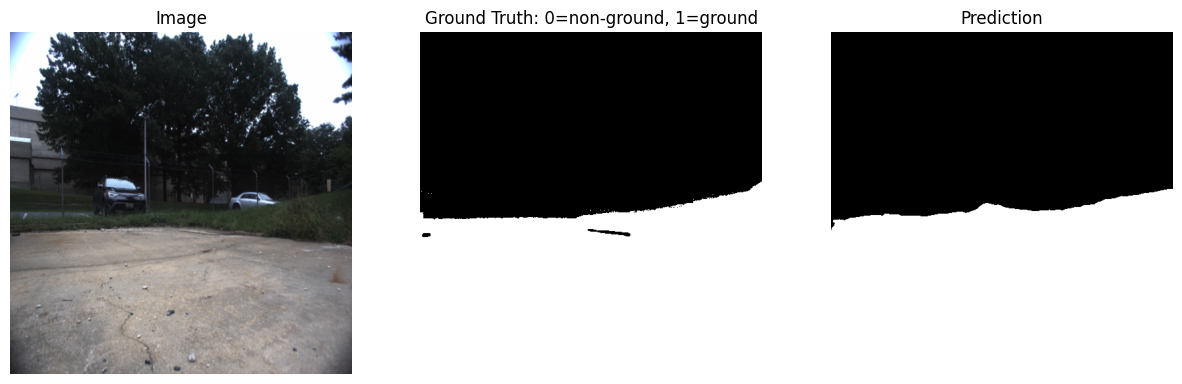

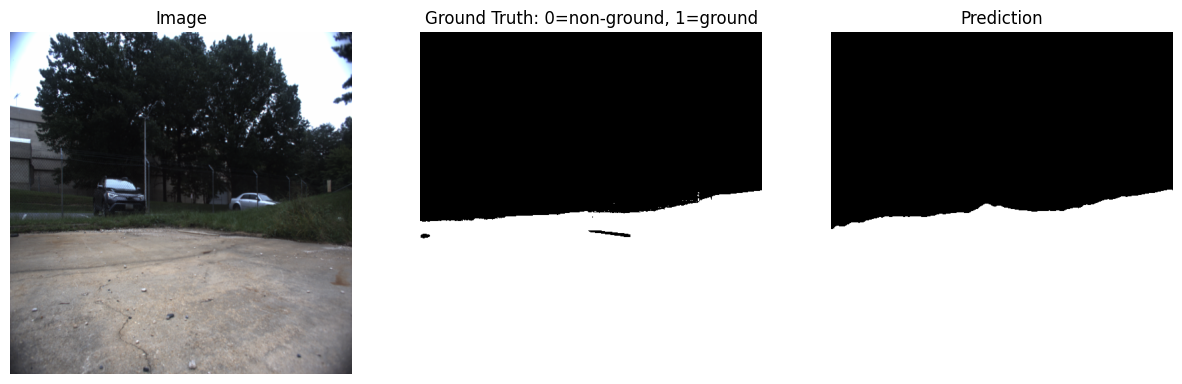

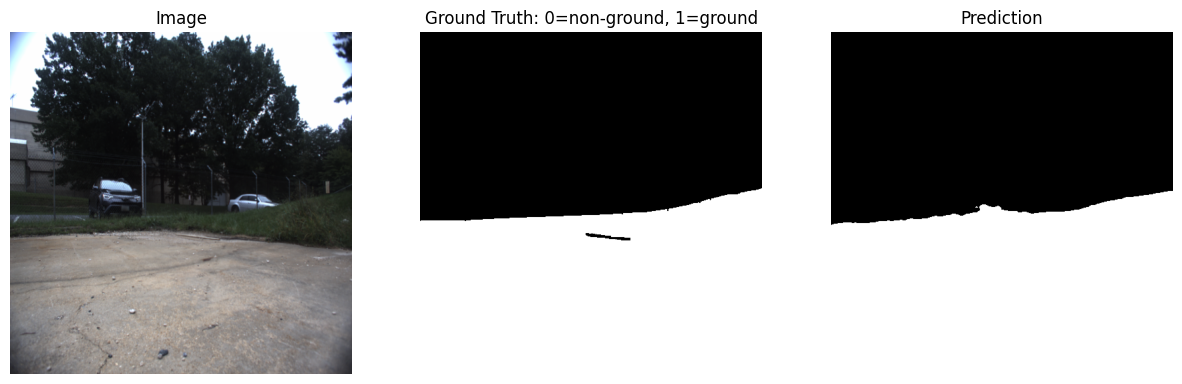

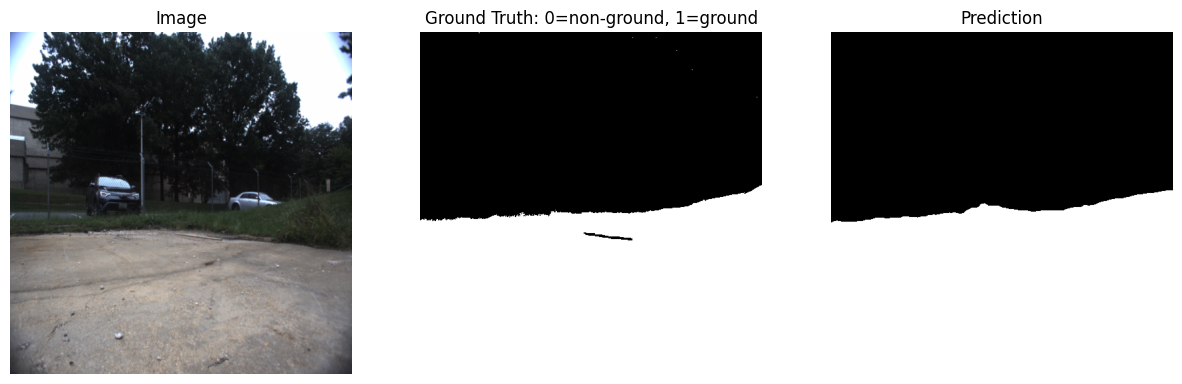

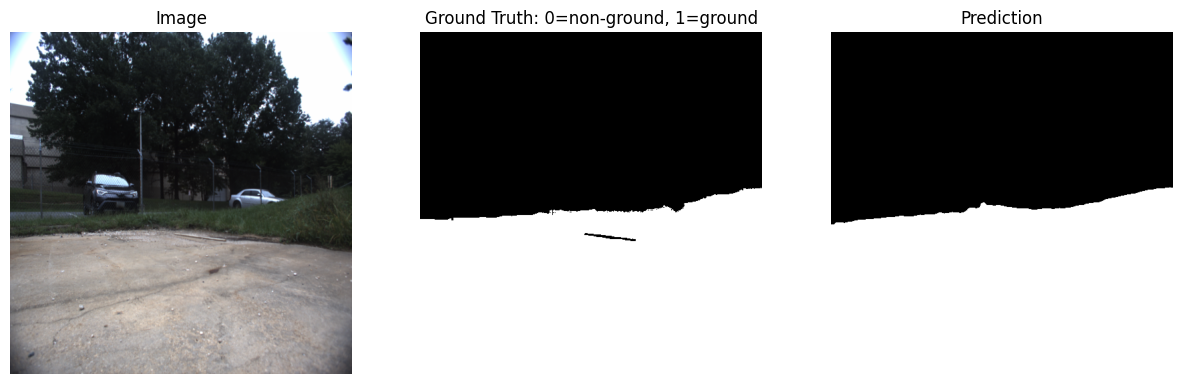

In [ ]:
import matplotlib.pyplot as plt

@torch.no_grad()
def visualize_binary_predictions(model, dataset, device, num_samples=3):
    model.eval()

    for i in range(num_samples):
        image, mask = dataset[i]

        input_tensor = image.unsqueeze(0).to(device)
        logits = model(input_tensor)
        pred = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()

        image_np = image.permute(1, 2, 0).cpu().numpy()

        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        image_np = std * image_np + mean
        image_np = np.clip(image_np, 0, 1)

        mask_np = mask.cpu().numpy()

        plt.figure(figsize=(15, 5))

        plt.subplot(1, 3, 1)
        plt.title("Image")
        plt.imshow(image_np)
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.title("Ground Truth: 0=non-ground, 1=ground")
        plt.imshow(mask_np, cmap="gray", vmin=0, vmax=1)
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.title("Prediction")
        plt.imshow(pred, cmap="gray", vmin=0, vmax=1)
        plt.axis("off")

        plt.show()


visualize_binary_predictions(model, val_dataset, device, num_samples=5)


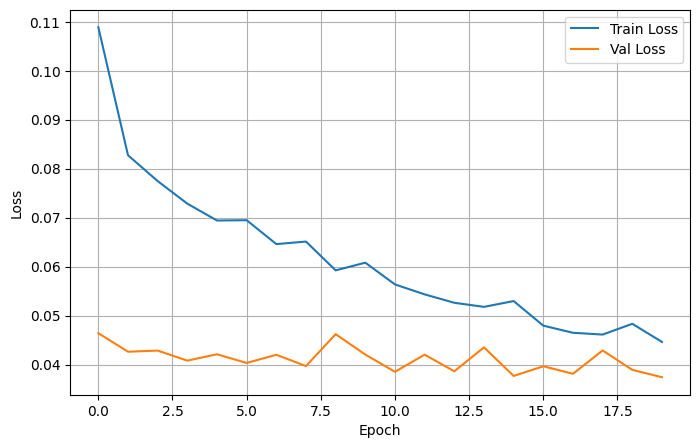

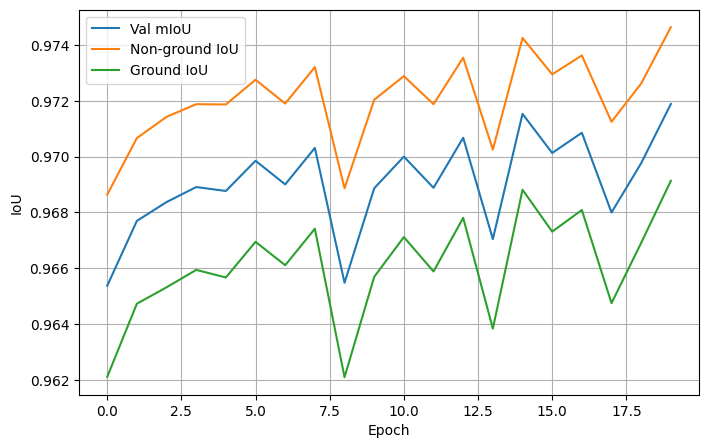

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["val_miou"], label="Val mIoU")
plt.plot(history["non_ground_iou"], label="Non-ground IoU")
plt.plot(history["ground_iou"], label="Ground IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from torch.utils.data import DataLoader
binary=True

test_dataset = RUGDProcessedBinaryDataset(
    image_dir=PROCESSED_ROOT / "images" / "test",
    mask_dir=PROCESSED_ROOT / "masks" / "test",
    transform=val_transform

)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

print("Test dataset:", len(test_dataset))
print("Test batches:", len(test_loader))

Test dataset: 1482
Test batches: 186


In [ ]:
images, masks = next(iter(test_loader))

print("Images shape:", images.shape)
print("Masks shape:", masks.shape)
print("Unique mask values:", torch.unique(masks))

Images shape: torch.Size([8, 3, 512, 512])
Masks shape: torch.Size([8, 512, 512])
Unique mask values: tensor([  0,   1, 255])


In [ ]:
from pathlib import Path
import torch
import segmentation_models_pytorch as smp

NUM_CLASSES = 2
IGNORE_INDEX = 255

MODEL_NAME = "SegFormer-B0"
ENCODER_NAME = "mit_b0"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reuse best_model_path from the training cell.

checkpoint = torch.load(
    best_model_path,
    map_location=device,
    weights_only=False
)

test_model = smp.Segformer(
    encoder_name=checkpoint.get("encoder_name", ENCODER_NAME),
    encoder_weights=None,
    in_channels=3,
    classes=NUM_CLASSES,
    activation=None,
)

test_model.load_state_dict(checkpoint["model_state_dict"])
test_model = test_model.to(device)
test_model.eval()

print("Loaded checkpoint from:", best_model_path)
print("Model name:", checkpoint.get("model_name", MODEL_NAME))
print("Best val mIoU:", checkpoint["best_val_miou"])
print("Checkpoint epoch:", checkpoint["epoch"])
print("Model device:", next(test_model.parameters()).device)


Loaded checkpoint from: /content/drive/MyDrive/IRP/02_rugd_baselines/checkpoints/segformer_b0_rugd_binary_ground_best_20epochs.pth
Model name: SegFormer-B0
Best val mIoU: 0.9718827133821002
Checkpoint epoch: 20
Model device: cuda:0


In [ ]:
# Duplicate batch-averaged test IoU evaluation removed.
# The next cell performs the final test evaluation using global/dataset-level IoU,
# consistent with validation and checkpoint selection.

In [ ]:
@torch.no_grad()
def evaluate_on_test_set(
    model,
    loader,
    criterion,
    device,
    num_classes=2,
    ignore_index=255,
):
    """
    Dataset-level test metrics accumulated over all valid pixels.

    Returns:
      loss, mIoU, class IoU, pixel accuracy,
      mean Dice, mean Precision, mean Recall,
      class Dice, class Precision, class Recall.
    """
    model.eval()

    total_loss = 0.0
    intersections = np.zeros(num_classes, dtype=np.float64)
    unions = np.zeros(num_classes, dtype=np.float64)
    tp = np.zeros(num_classes, dtype=np.float64)
    fp = np.zeros(num_classes, dtype=np.float64)
    fn = np.zeros(num_classes, dtype=np.float64)

    total_correct = 0
    total_valid = 0

    for images, masks in tqdm(loader, desc="Testing"):
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        logits = model(images)
        loss = criterion(logits, masks)
        preds = torch.argmax(logits, dim=1)

        total_loss += loss.item() * images.size(0)

        preds_np = preds.detach().cpu().numpy()
        masks_np = masks.detach().cpu().numpy()
        valid = masks_np != ignore_index

        total_correct += ((preds_np == masks_np) & valid).sum()
        total_valid += valid.sum()

        for cls in range(num_classes):
            pred_cls = (preds_np == cls) & valid
            target_cls = (masks_np == cls) & valid

            cls_tp = np.logical_and(pred_cls, target_cls).sum()
            cls_fp = np.logical_and(pred_cls, np.logical_not(target_cls) & valid).sum()
            cls_fn = np.logical_and(np.logical_not(pred_cls) & valid, target_cls).sum()

            tp[cls] += cls_tp
            fp[cls] += cls_fp
            fn[cls] += cls_fn

            intersections[cls] += cls_tp
            unions[cls] += np.logical_or(pred_cls, target_cls).sum()

    class_ious = {}
    class_dice = {}
    class_precision = {}
    class_recall = {}

    for cls in range(num_classes):
        class_ious[cls] = (
            float(intersections[cls] / unions[cls])
            if unions[cls] > 0 else None
        )

        dice_denom = 2 * tp[cls] + fp[cls] + fn[cls]
        precision_denom = tp[cls] + fp[cls]
        recall_denom = tp[cls] + fn[cls]

        class_dice[cls] = (
            float((2 * tp[cls]) / dice_denom)
            if dice_denom > 0 else None
        )
        class_precision[cls] = (
            float(tp[cls] / precision_denom)
            if precision_denom > 0 else None
        )
        class_recall[cls] = (
            float(tp[cls] / recall_denom)
            if recall_denom > 0 else None
        )

    mean_iou = float(np.mean([v for v in class_ious.values() if v is not None]))
    mean_dice = float(np.mean([v for v in class_dice.values() if v is not None]))
    mean_precision = float(np.mean([v for v in class_precision.values() if v is not None]))
    mean_recall = float(np.mean([v for v in class_recall.values() if v is not None]))

    pixel_accuracy = float(total_correct / total_valid)
    test_loss = float(total_loss / len(loader.dataset))

    return (
        test_loss,
        mean_iou,
        class_ious,
        pixel_accuracy,
        mean_dice,
        mean_precision,
        mean_recall,
        class_dice,
        class_precision,
        class_recall,
    )


(
    test_loss,
    test_miou,
    test_class_iou,
    test_pixel_acc,
    test_mean_dice,
    test_mean_precision,
    test_mean_recall,
    test_class_dice,
    test_class_precision,
    test_class_recall,
) = evaluate_on_test_set(
    model=test_model,
    loader=test_loader,
    criterion=criterion,
    device=device,
    num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX,
)

print("\n===== Final Test Set Results =====")
print(f"Test Loss:            {test_loss:.4f}")
print(f"Non-ground IoU:       {test_class_iou[0]:.4f}")
print(f"Ground IoU:           {test_class_iou[1]:.4f}")
print(f"mIoU:                 {test_miou:.4f}")
print(f"Mean Dice:            {test_mean_dice:.4f}")
print(f"Mean Precision:       {test_mean_precision:.4f}")
print(f"Mean Recall:          {test_mean_recall:.4f}")
print(f"Pixel Accuracy:       {test_pixel_acc:.4f}")

print("\nPer-class metrics:")
print(
    f"Non-ground -> Dice={test_class_dice[0]:.4f}, "
    f"Precision={test_class_precision[0]:.4f}, "
    f"Recall={test_class_recall[0]:.4f}"
)
print(
    f"Ground     -> Dice={test_class_dice[1]:.4f}, "
    f"Precision={test_class_precision[1]:.4f}, "
    f"Recall={test_class_recall[1]:.4f}"
)

Testing: 100%|██████████| 186/186 [00:17<00:00, 10.48it/s]


===== Final Test Set Results =====
Test Loss:            0.1903
Non-ground IoU:       0.8884
Ground IoU:           0.8477
mIoU:                 0.8680
Mean Dice:            0.9292
Mean Precision:       0.9247
Mean Recall:          0.9378
Pixel Accuracy:       0.9312

Per-class metrics:
Non-ground -> Dice=0.9409, Precision=0.9783, Recall=0.9063
Ground     -> Dice=0.9176, Precision=0.8711, Recall=0.9692


In [ ]:
import time


@torch.no_grad()
def measure_inference_speed(
    model,
    loader,
    device,
    warmup_batches=10,
):
    """
    Measure model-only inference throughput on the current device.

    CUDA synchronization is used so GPU timing is accurate.
    The same function should be used for all baseline models.
    """
    model.eval()

    # Warm-up
    for batch_idx, (images, _) in enumerate(loader):
        images = images.to(device, non_blocking=True)
        _ = model(images)

        if batch_idx + 1 >= warmup_batches:
            break

    if device.type == "cuda":
        torch.cuda.synchronize()

    total_time = 0.0
    total_images = 0

    for images, _ in tqdm(loader, desc="Measuring inference speed"):
        images = images.to(device, non_blocking=True)

        if device.type == "cuda":
            torch.cuda.synchronize()

        start_time = time.perf_counter()
        _ = model(images)

        if device.type == "cuda":
            torch.cuda.synchronize()

        elapsed = time.perf_counter() - start_time

        total_time += elapsed
        total_images += images.size(0)

    mean_inference_time_ms = (total_time / total_images) * 1000.0
    fps = total_images / total_time

    print("\n===== Inference Speed =====")
    print(f"Mean inference time: {mean_inference_time_ms:.3f} ms/image")
    print(f"FPS:                 {fps:.3f}")

    return float(mean_inference_time_ms), float(fps)


mean_inference_time_ms, fps = measure_inference_speed(
    model=test_model,
    loader=test_loader,
    device=device,
    warmup_batches=10,
)

Measuring inference speed: 100%|██████████| 186/186 [00:16<00:00, 11.38it/s]


===== Inference Speed =====
Mean inference time: 2.827 ms/image
FPS:                 353.732


In [ ]:
import json

test_results = {
    "model_name": MODEL_NAME,
    "encoder_name": ENCODER_NAME,
    "test_loss": float(test_loss),

    "non_ground_iou": float(test_class_iou[0]),
    "ground_iou": float(test_class_iou[1]),
    "miou": float(test_miou),

    "non_ground_dice": float(test_class_dice[0]),
    "ground_dice": float(test_class_dice[1]),
    "mean_dice": float(test_mean_dice),

    "non_ground_precision": float(test_class_precision[0]),
    "ground_precision": float(test_class_precision[1]),
    "mean_precision": float(test_mean_precision),

    "non_ground_recall": float(test_class_recall[0]),
    "ground_recall": float(test_class_recall[1]),
    "mean_recall": float(test_mean_recall),

    "pixel_accuracy": float(test_pixel_acc),

    "mean_inference_time_ms": float(mean_inference_time_ms),
    "fps": float(fps),

    "checkpoint_path": str(best_model_path),
    "checkpoint_epoch": int(checkpoint["epoch"]),
    "best_val_miou": float(checkpoint["best_val_miou"]),
    "num_classes": NUM_CLASSES,
    "ignore_index": IGNORE_INDEX,
}

result_path = RESULTS_DIR / "test_summary.json"

with open(result_path, "w") as f:
    json.dump(test_results, f, indent=4)

print("Saved test results to:", result_path)
print(test_results)

Saved test results to: /content/drive/MyDrive/IRP/02_rugd_baselines/results/segformer_b0_20epochs/test_summary.json
{'model_name': 'SegFormer-B0', 'encoder_name': 'mit_b0', 'test_loss': 0.190283665702491, 'non_ground_iou': 0.8884138657309815, 'ground_iou': 0.8476822072213447, 'miou': 0.8680480364761631, 'non_ground_dice': 0.940910127650527, 'ground_dice': 0.9175627755772352, 'mean_dice': 0.9292364516138811, 'non_ground_precision': 0.978303530761587, 'ground_precision': 0.8711107097400196, 'mean_precision': 0.9247071202508033, 'non_ground_recall': 0.9062700391347861, 'ground_recall': 0.9692480234989386, 'mean_recall': 0.9377590313168623, 'pixel_accuracy': 0.9311622271765335, 'mean_inference_time_ms': 2.827001892037957, 'fps': 353.73163449816803, 'checkpoint_path': '/content/drive/MyDrive/IRP/02_rugd_baselines/checkpoints/segformer_b0_rugd_binary_ground_best_20epochs.pth', 'checkpoint_epoch': 20, 'best_val_miou': 0.9718827133821002, 'num_classes': 2, 'ignore_index': 255}


In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from tqdm import tqdm


def compute_single_image_metrics(pred, target, num_classes=2, ignore_index=255):
    valid = target != ignore_index
    class_ious = {}

    for cls in range(num_classes):
        pred_cls = (pred == cls) & valid
        target_cls = (target == cls) & valid

        intersection = np.logical_and(pred_cls, target_cls).sum()
        union = np.logical_or(pred_cls, target_cls).sum()

        class_ious[cls] = None if union == 0 else intersection / union

    valid_ious = [iou for iou in class_ious.values() if iou is not None]
    miou = float(np.mean(valid_ious)) if valid_ious else None

    valid_pixels = int(valid.sum())
    pixel_accuracy = (
        float(((pred == target) & valid).sum() / valid_pixels)
        if valid_pixels > 0 else None
    )

    return miou, class_ious, pixel_accuracy, valid_pixels

In [ ]:
@torch.no_grad()
def evaluate_each_test_image(model, dataset, device, num_classes=2, ignore_index=255):
    model.eval()
    results = []

    for idx in tqdm(range(len(dataset)), desc="Evaluating each test image"):
        image, mask = dataset[idx]

        logits = model(image.unsqueeze(0).to(device))
        pred = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()
        mask_np = mask.cpu().numpy()

        miou, class_ious, pixel_accuracy, valid_pixels = compute_single_image_metrics(
            pred=pred,
            target=mask_np,
            num_classes=num_classes,
            ignore_index=ignore_index,
        )

        image_path = dataset.image_paths[idx] if hasattr(dataset, "image_paths") else None

        results.append({
            "idx": idx,
            "image_path": str(image_path) if image_path is not None else None,
            "miou": miou,
            "non_ground_iou": class_ious[0],
            "ground_iou": class_ious[1],
            "pixel_accuracy": pixel_accuracy,
            "valid_pixels": valid_pixels,
        })

    return results


per_image_results = evaluate_each_test_image(
    model=test_model,
    dataset=test_dataset,
    device=device,
    num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX,
)

Evaluating each test image: 100%|██████████| 1482/1482 [00:46<00:00, 31.97it/s]


In [ ]:
def format_iou(value):
    if value is None:
        return "None"
    return f"{value:.4f}"

In [ ]:
valid_results = [r for r in per_image_results if r["miou"] is not None]

top5_best = sorted(valid_results, key=lambda x: x["miou"], reverse=True)[:5]
bottom5_worst = sorted(valid_results, key=lambda x: x["miou"])[:5]

print("===== Top-5 Best Test Images =====")
for rank, r in enumerate(top5_best, 1):
    print(
        f"rank={rank}, idx={r['idx']}, "
        f"mIoU={format_iou(r['miou'])}, "
        f"non-ground IoU={format_iou(r['non_ground_iou'])}, "
        f"ground IoU={format_iou(r['ground_iou'])}, "
        f"pixel accuracy={format_iou(r['pixel_accuracy'])}, "
        f"path={r['image_path']}"
    )

print("\n===== Bottom-5 Worst Test Images =====")
for rank, r in enumerate(bottom5_worst, 1):
    print(
        f"rank={rank}, idx={r['idx']}, "
        f"mIoU={format_iou(r['miou'])}, "
        f"non-ground IoU={format_iou(r['non_ground_iou'])}, "
        f"ground IoU={format_iou(r['ground_iou'])}, "
        f"pixel accuracy={format_iou(r['pixel_accuracy'])}, "
        f"path={r['image_path']}"
    )

===== Top-5 Best Test Images =====
rank=1, idx=488, mIoU=0.9993, non-ground IoU=0.9991, ground IoU=0.9995, pixel accuracy=0.9997, path=/content/content/RUGD_processed/images/test/creek_creek_02441.png
rank=2, idx=1464, mIoU=0.9966, non-ground IoU=0.9966, ground IoU=0.9965, pixel accuracy=0.9983, path=/content/content/RUGD_processed/images/test/village_village_00498.png
rank=3, idx=166, mIoU=0.9964, non-ground IoU=0.9971, ground IoU=0.9957, pixel accuracy=0.9983, path=/content/content/RUGD_processed/images/test/creek_creek_00831.png
rank=4, idx=1449, mIoU=0.9955, non-ground IoU=0.9958, ground IoU=0.9953, pixel accuracy=0.9978, path=/content/content/RUGD_processed/images/test/village_village_00423.png
rank=5, idx=165, mIoU=0.9952, non-ground IoU=0.9963, ground IoU=0.9941, pixel accuracy=0.9977, path=/content/content/RUGD_processed/images/test/creek_creek_00826.png

===== Bottom-5 Worst Test Images =====
rank=1, idx=702, mIoU=0.2265, non-ground IoU=0.4530, ground IoU=0.0000, pixel accurac

In [ ]:
def make_binary_vis(mask):
    """
    0   = non-ground -> black
    1   = ground     -> white
    255 = ignore     -> gray
    """
    vis = np.zeros_like(mask, dtype=np.uint8)
    vis[mask == 0] = 0
    vis[mask == 1] = 1
    vis[mask == 255] = 2
    return vis


def make_error_map(pred, target, ignore_index=255):
    """
    Error-only map:
      black = correct or ignored
      red   = false ground
      blue  = false non-ground
    """
    error_rgb = np.zeros((*target.shape, 3), dtype=np.uint8)
    valid = target != ignore_index

    false_ground = (target == 0) & (pred == 1) & valid
    false_non_ground = (target == 1) & (pred == 0) & valid

    error_rgb[false_ground] = [255, 0, 0]
    error_rgb[false_non_ground] = [0, 0, 255]

    return error_rgb


def denormalize_image(image_tensor):
    image_np = image_tensor.permute(1, 2, 0).cpu().numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image_np = std * image_np + mean
    return np.clip(image_np, 0, 1)


def make_prediction_overlay(image_np, pred, alpha=0.42):
    overlay = image_np.copy()
    ground = pred == 1

    green = np.zeros_like(image_np)
    green[..., 1] = 1.0

    overlay[ground] = (
        (1.0 - alpha) * image_np[ground]
        + alpha * green[ground]
    )
    return np.clip(overlay, 0, 1)

In [ ]:
@torch.no_grad()
def visualize_selected_test_samples(
    model,
    dataset,
    device,
    selected_results,
    title_prefix="",
    save_dir=None,
):
    """
    Five-column qualitative visualization:
    RGB | GT ground | SegFormer-B0 prediction | prediction overlay | errors
    """
    model.eval()

    binary_cmap = ListedColormap(["black", "white", "gray"])

    for rank, r in enumerate(selected_results, 1):
        idx = r["idx"]
        image, mask = dataset[idx]

        logits = model(image.unsqueeze(0).to(device))
        pred = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()

        mask_np = mask.cpu().numpy()
        image_np = denormalize_image(image)

        mask_vis = make_binary_vis(mask_np)
        overlay = make_prediction_overlay(image_np, pred)
        error_map = make_error_map(pred, mask_np, ignore_index=IGNORE_INDEX)

        fig, axes = plt.subplots(1, 5, figsize=(25, 5))

        path_text = r["image_path"] if r["image_path"] is not None else f"idx={idx}"
        fig.suptitle(
            f"{title_prefix} #{rank} | {path_text}\n"
            f"mIoU={format_iou(r['miou'])}, "
            f"non-ground IoU={format_iou(r['non_ground_iou'])}, "
            f"ground IoU={format_iou(r['ground_iou'])}",
            fontsize=11,
            y=1.04,
        )

        axes[0].imshow(image_np)
        axes[0].set_title("RGB")

        axes[1].imshow(mask_vis, cmap=binary_cmap, vmin=0, vmax=2)
        axes[1].set_title("GT ground\nwhite=ground, gray=ignore")

        axes[2].imshow(
            pred,
            cmap=ListedColormap(["black", "white"]),
            vmin=0,
            vmax=1,
        )
        axes[2].set_title("SegFormer-B0 prediction")

        axes[3].imshow(overlay)
        axes[3].set_title("Prediction overlay\ngreen=predicted ground")

        axes[4].imshow(error_map)
        axes[4].set_title(
            "Errors\n"
            "red=false ground\n"
            "blue=false non-ground"
        )

        for ax in axes:
            ax.axis("off")

        plt.tight_layout()

        if save_dir is not None:
            save_dir = Path(save_dir)
            save_dir.mkdir(parents=True, exist_ok=True)
            safe_prefix = title_prefix.lower().replace(" ", "_").replace("-", "")
            out_path = save_dir / f"{safe_prefix}_rank_{rank:02d}_idx_{idx}.png"
            plt.savefig(out_path, dpi=200, bbox_inches="tight")
            print("Saved:", out_path)

        plt.show()

In [ ]:
RANKED_VIS_DIR = RESULTS_DIR / "ranked_cases"
RANKED_VIS_DIR.mkdir(parents=True, exist_ok=True)

visualize_selected_test_samples(
    model=test_model,
    dataset=test_dataset,
    device=device,
    selected_results=top5_best,
    title_prefix="Top-5 Best",
    save_dir=RANKED_VIS_DIR,
)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
visualize_selected_test_samples(
    model=test_model,
    dataset=test_dataset,
    device=device,
    selected_results=bottom5_worst,
    title_prefix="Bottom-5 Worst",
    save_dir=RANKED_VIS_DIR,
)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import pandas as pd
from pathlib import Path

df_results = pd.DataFrame(per_image_results)

csv_path = RESULTS_DIR / "test_per_image_metrics.csv"
df_results.to_csv(csv_path, index=False)

print("Saved per-image metrics to:", csv_path)
df_results.head()


Saved per-image metrics to: /content/drive/MyDrive/IRP/02_rugd_baselines/results/segformer_b0_20epochs/test_per_image_metrics.csv


,idx,image_path,miou,non_ground_iou,ground_iou,pixel_accuracy,valid_pixels
0,0,/content/content/RUGD_processed/images/test/cr...,0.856620,0.872745,0.840495,0.923825,261437
1,1,/content/content/RUGD_processed/images/test/cr...,0.849841,0.866211,0.833471,0.919868,261407
2,2,/content/content/RUGD_processed/images/test/cr...,0.869850,0.886554,0.853147,0.931620,261116
3,3,/content/content/RUGD_processed/images/test/cr...,0.896565,0.921473,0.871658,0.948787,258858
4,4,/content/content/RUGD_processed/images/test/cr...,0.931354,0.944412,0.918295,0.965787,255547


Saved histogram to: /content/drive/MyDrive/IRP/02_rugd_baselines/results/segformer_b0_20epochs/per_image_miou_distribution.png


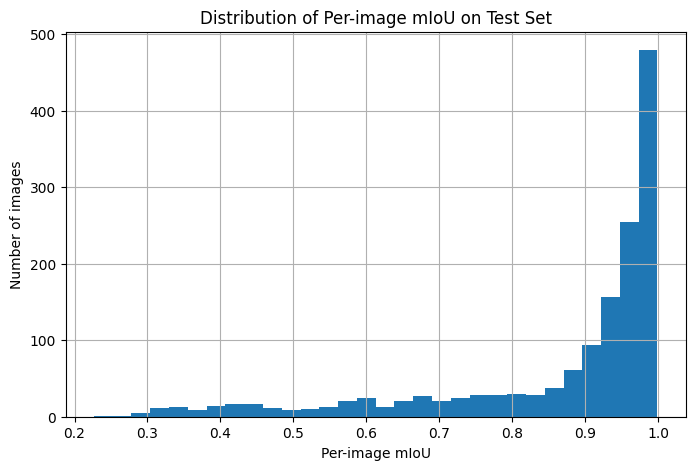

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df_results["miou"].dropna(), bins=30)
plt.xlabel("Per-image mIoU")
plt.ylabel("Number of images")
plt.title("Distribution of Per-image mIoU on Test Set")
plt.grid(True)
hist_path = RESULTS_DIR / "per_image_miou_distribution.png"
plt.savefig(hist_path, dpi=200, bbox_inches="tight")
print("Saved histogram to:", hist_path)
plt.show()

In [ ]:
# Redundant generic 3-column visualization removed.
# Ranked Top-5 / Bottom-5 samples are shown above in the unified 5-column layout.

In [ ]:
# See the ranked Top-5 / Bottom-5 five-column visualizations above.

In [ ]:
# Redundant standalone error-map visualization removed.
# Error maps are already included as the fifth column in the ranked visualizations.